<a href="https://colab.research.google.com/github/AugustoSSerpa/hands_on_spr_2026/blob/main/hands_on_spr_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩻 Foundation Models para Radiologia: ImageNet vs. Domínio Clínico
## Hands-on Vibe Coding — Sociedade Paulista de Radiologia 2026

---

### A Pergunta Central

Um modelo treinado em fotos do cotidiano (gatos, carros, 1.000 classes) tem o mesmo valor como extrator de características radiológicas que um modelo treinado em **880 mil raios-X de tórax**?

Neste hands-on você vai responder isso experimentalmente:

| Extrator | Pré-treinamento | O que aprendeu |
|---|---|---|
| **EfficientNetB0** | ImageNet (1,28M fotos naturais) | Bordas, texturas, formas gerais |
| **RAD-DINO** | 880K+ raios-X de tórax (Microsoft, 2024) | Opacidades, consolidações, textura pulmonar |

**Experimento:** congele ambos os backbones → treine a **mesma cabeça classificadora** em cada → compare o t-SNE dos embeddings e as métricas no conjunto de teste.

---

### Dataset: PneumoniaMNIST

- **1.000 imagens** de raio-X de tórax (64×64 pixels, subsample reproduzível)
- **2 classes:** Normal vs Pneumonia Bacteriana/Viral
- Download automático via `pip install medmnist` — sem login, sem cadastro
- Fonte: Kermany et al., *Cell* 2018 | Licença: CC BY 4.0

---

### Como usar este notebook

1. **Ative o GPU T4:** Menu `Ambiente de execução` → `Alterar tipo de hardware` → T4 GPU → Salvar → Reconectar
2. Para **cada Prompt Card**, copie o prompt e cole no **Gemini** (ícone ✦ ou `Ctrl+Shift+I`)
3. O Gemini irá gerara um código na célula que corresponde a cada prompt, aí é só executar
4. Tudo é construído via Gemini — não há células pré-preenchidas

---

### Prompt card 0 (Setup e Preparação)

In [109]:
# Instalar bibliotecas necessárias
!pip install -q medmnist transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.2 MB/s eta 0:00:00


In [110]:
# Importar bibliotecas
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

from medmnist import INFO, Evaluator
import medmnist

from transformers import AutoImageProcessor, AutoModel

import os
import gc


In [111]:
# Definir SEED para reprodutibilidade
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
random.seed(SEED)

# Configurar DEVICE para usar GPU se disponível
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {DEVICE}")

Usando dispositivo: cuda


In [112]:
# Funções auxiliares
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

def free_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()



### Prompt card 1 (Carregar e Visualizar o Dataset)

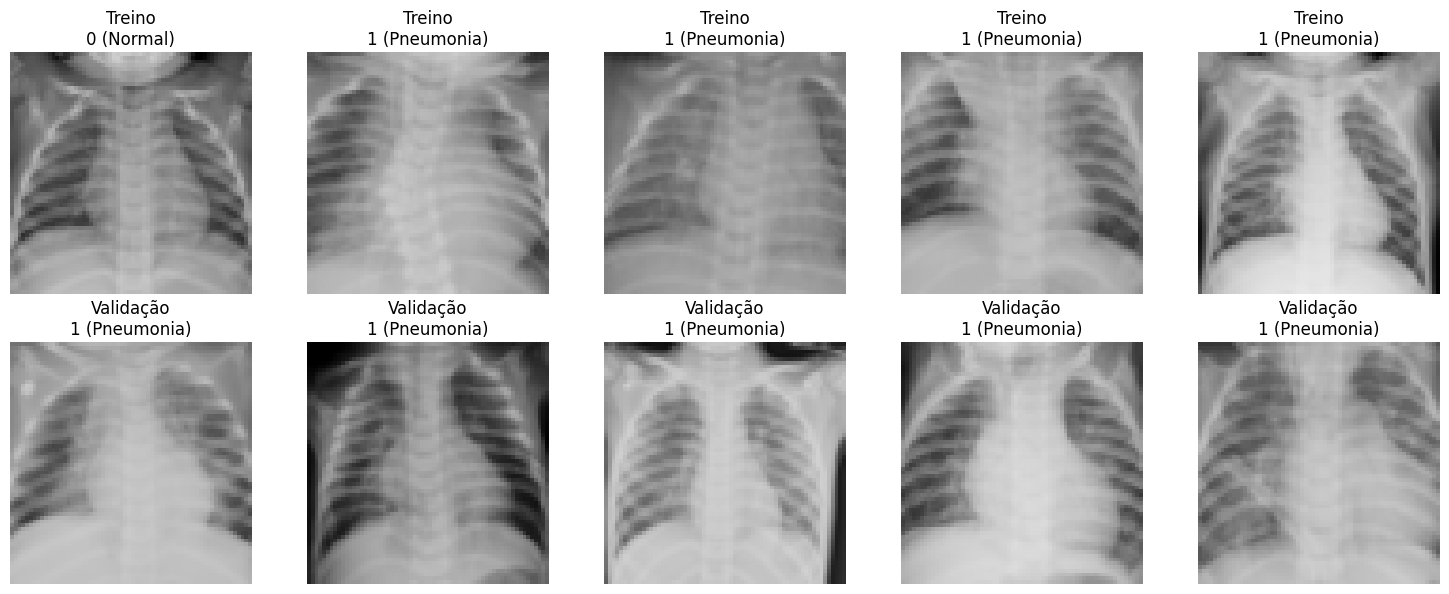

Treino: (800, 64, 64, 3), Labels: (800,)
Validação: (200, 64, 64, 3), Labels: (200,)


In [113]:
import numpy as np
from medmnist import PneumoniaMNIST
import matplotlib.pyplot as plt
import random

# 1. Carregar dataset (resolução 64x64)
size = 64
data_flag = 'pneumoniamnist'

# Baixando e carregando os dados completos
full_train_dataset = PneumoniaMNIST(split='train', size=size, download=True)
full_val_dataset = PneumoniaMNIST(split='val', size=size, download=True)
full_test_dataset = PneumoniaMNIST(split='test', size=size, download=True)

# Combinar para extrair exatamente 1000 imagens para o experimento
all_imgs = np.concatenate([full_train_dataset.imgs, full_val_dataset.imgs, full_test_dataset.imgs], axis=0)
all_labels = np.concatenate([full_train_dataset.labels, full_val_dataset.labels, full_test_dataset.labels], axis=0).flatten()

# Selecionar as primeiras 1000 imagens para consistência
X_subset = all_imgs[:1000]
y_subset = all_labels[:1000]

# 2. Divisão de Treino (80%) e Validação (20%)
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=SEED, stratify=y_subset
)

# 3. Pré-processamento: Normalização [0,1] e Conversão para 3 canais (RGB)
def preprocess_images(imgs):
    # Normalizar
    imgs = imgs.astype(np.float32) / 255.0
    # Expandir para 3 canais se for grayscale (N, H, W) -> (N, H, W, 3)
    if len(imgs.shape) == 3:
        imgs = np.stack([imgs] * 3, axis=-1)
    return imgs

x_train = preprocess_images(x_train)
x_val = preprocess_images(x_val)

# 4. Visualização
class_names = ['Normal', 'Pneumonia']
splits_to_show = [('Treino', x_train, y_train), ('Validação', x_val, y_val)]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for row_idx, (name, images, labels) in enumerate(splits_to_show):
    indices = random.sample(range(len(images)), 5)
    for col_idx, idx in enumerate(indices):
        ax = axes[row_idx, col_idx]
        ax.imshow(images[idx])
        ax.set_title(f"{name}\n{labels[idx]} ({class_names[labels[idx]]})")
        ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Treino: {x_train.shape}, Labels: {y_train.shape}")
print(f"Validação: {x_val.shape}, Labels: {y_val.shape}")

### Prompt card 2 (Extração de Embeddings + t-SNE)

In [114]:
import torch
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
from transformers import AutoImageProcessor, AutoModel
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. Carregar Modelos
effnet_model = models.efficientnet_b0(weights='IMAGENET1K_V1').to(DEVICE)
effnet_model.eval()
# Remover a cabeça de classificação para pegar o embedding (1280 dim)
effnet_model.classifier = torch.nn.Identity()

dino_processor = AutoImageProcessor.from_pretrained('microsoft/rad-dino')
dino_model = AutoModel.from_pretrained('microsoft/rad-dino').to(DEVICE)
dino_model.eval()

# Congelar parâmetros
for p in effnet_model.parameters(): p.requires_grad = False
for p in dino_model.parameters(): p.requires_grad = False

# 2. Preparar Transforms para EffNet (ImageNet standard)
eff_transform = T.Compose([
    T.Resize((224, 224)),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def get_embeddings():
    emb_eff, emb_dino, labels = [], [], []

    # Processar todas as 1000 imagens do subset (X_subset e y_subset definidos no card anterior)
    for img_arr, label in zip(X_subset, y_subset):
        # Converter array [0,255] para PIL
        img_pil = Image.fromarray(img_arr.astype('uint8')).convert('RGB')

        # Embedding EfficientNetB0
        img_eff = T.ToTensor()(img_pil).unsqueeze(0).to(DEVICE)
        img_eff = eff_transform(img_eff)
        with torch.no_grad():
            out_eff = effnet_model(img_eff)
            emb_eff.append(out_eff.cpu().numpy().flatten())

        # Embedding RAD-DINO
        inputs_dino = dino_processor(images=img_pil, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            out_dino = dino_model(**inputs_dino)
            # Token CLS: [batch, 0, hidden_dim]
            cls_token = out_dino.last_hidden_state[:, 0, :]
            emb_dino.append(cls_token.cpu().numpy().flatten())

        labels.append(label)

    return np.array(emb_eff), np.array(emb_dino), np.array(labels)

print("Extraindo embeddings... (isso pode levar um minuto)")
all_emb_eff, all_emb_dino, all_labels_final = get_embeddings()
print(f"Embeddings EffNet: {all_emb_eff.shape}")
print(f"Embeddings RAD-DINO: {all_emb_dino.shape}")

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Extraindo embeddings... (isso pode levar um minuto)
Embeddings EffNet: (1000, 1280)
Embeddings RAD-DINO: (1000, 768)


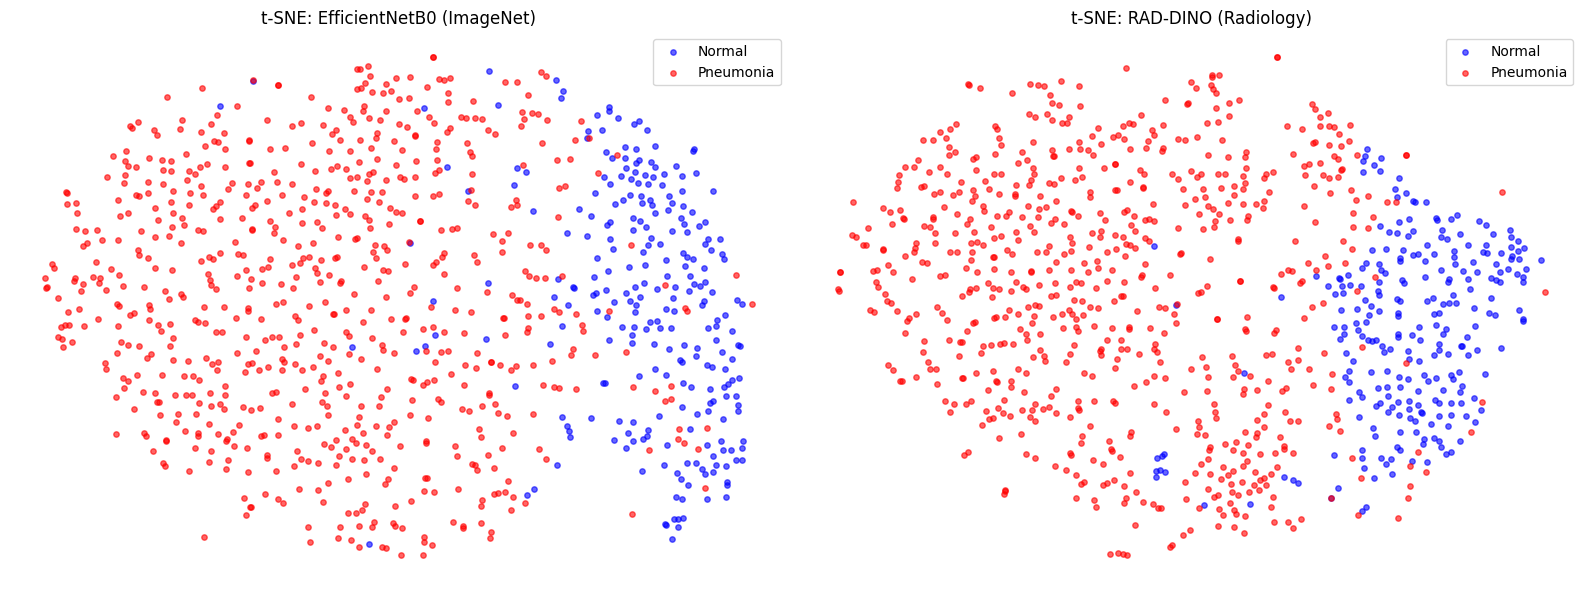

In [115]:
# 3. Gerar t-SNE
tsne = TSNE(n_components=2, random_state=SEED)
vis_eff = tsne.fit_transform(all_emb_eff)
vis_dino = tsne.fit_transform(all_emb_dino)

# 4. Plotar Resultados
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['blue', 'red']
class_labels = ['Normal', 'Pneumonia']

for i, (vis, title) in enumerate([(vis_eff, 'EfficientNetB0 (ImageNet)'), (vis_dino, 'RAD-DINO (Radiology)')]):
    for cl in [0, 1]:
        idx = np.where(all_labels_final == cl)
        axes[i].scatter(vis[idx, 0], vis[idx, 1], c=colors[cl], label=class_labels[cl], alpha=0.6, s=15)
    axes[i].set_title(f"t-SNE: {title}")
    axes[i].legend()
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Prompt card 3 (Classificador 1: EfficientNetB0 - ImageNet)
Nesta etapa, utilizamos os embeddings gerados pelo backbone treinado no ImageNet para alimentar um classificador SVM.

Treinando SVM para EfficientNetB0...

--- Métricas: EfficientNetB0 ---
ACCURACY: 0.9450
AUC: 0.9782
SENSITIVITY: 0.9527
SPECIFICITY: 0.9231
PPV: 0.9724
NPV: 0.8727


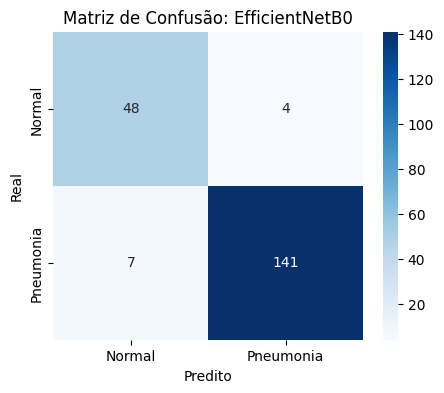

In [116]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# 1. Preparar os dados (usando a divisão do Card 1)
# Como extraímos embeddings para as 1000 imagens no Card 2 (all_emb_eff),
# vamos usar os mesmos índices da divisão original.

# Re-fazendo a divisão dos embeddings para garantir consistência com x_train/x_val
train_idx, val_idx = train_test_split(
    range(1000), test_size=0.2, random_state=SEED, stratify=y_subset
)

X_train_eff = all_emb_eff[train_idx]
y_train_eff = all_labels_final[train_idx]
X_val_eff = all_emb_eff[val_idx]
y_val_eff = all_labels_final[val_idx]

# 2. Normalização (Essencial para SVM)
scaler_eff = StandardScaler()
X_train_eff_scaled = scaler_eff.fit_transform(X_train_eff)
X_val_eff_scaled = scaler_eff.transform(X_val_eff)

# 3. Treinar SVM
print("Treinando SVM para EfficientNetB0...")
svm_eff = SVC(kernel='linear', probability=True, random_state=SEED)
svm_eff.fit(X_train_eff_scaled, y_train_eff)

# 4. Predições
y_pred_eff = svm_eff.predict(X_val_eff_scaled)
y_probs_eff = svm_eff.predict_proba(X_val_eff_scaled)[:, 1]

# 5. Calcular Métricas
cm_eff = confusion_matrix(y_val_eff, y_pred_eff)
tn, fp, fn, tp = cm_eff.ravel()

metrics_eff = {
    'model_name': 'EfficientNetB0 (ImageNet)',
    'accuracy': accuracy_score(y_val_eff, y_pred_eff),
    'auc': roc_auc_score(y_val_eff, y_probs_eff),
    'sensitivity': tp / (tp + fn),
    'specificity': tn / (tn + fp),
    'ppv': tp / (tp + fp),
    'npv': tn / (tn + fn)
}

# Exibir Resultados
print("\n--- Métricas: EfficientNetB0 ---")
for k, v in metrics_eff.items():
    if k != 'model_name': print(f"{k.upper()}: {v:.4f}")

# 6. Plotar Matriz de Confusão
plt.figure(figsize=(5, 4))
sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Matriz de Confusão: EfficientNetB0')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.show()

### Prompt card 4 (Classificador 2: RAD-DINO - Radiologia)
Nesta etapa, utilizamos os embeddings gerados pelo RAD-DINO (especializado em Radiologia) para treinar o classificador SVM e comparar com o baseline.

Treinando SVM para RAD-DINO...

--- Métricas: RAD-DINO ---
ACCURACY: 0.9500
AUC: 0.9938
SENSITIVITY: 0.9797
SPECIFICITY: 0.8654
PPV: 0.9539
NPV: 0.9375


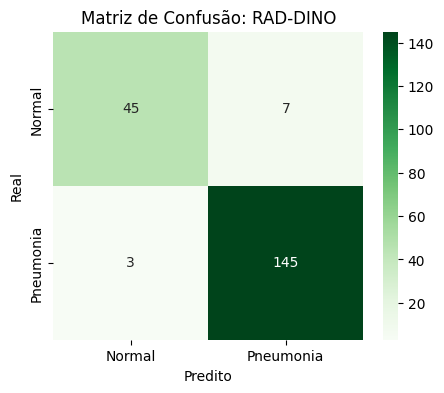

In [117]:
# 1. Preparar os dados (usando os mesmos índices de divisão para fair comparison)
X_train_dino = all_emb_dino[train_idx]
y_train_dino = all_labels_final[train_idx]
X_val_dino = all_emb_dino[val_idx]
y_val_dino = all_labels_final[val_idx]

# 2. Normalização
scaler_dino = StandardScaler()
X_train_dino_scaled = scaler_dino.fit_transform(X_train_dino)
X_val_dino_scaled = scaler_dino.transform(X_val_dino)

# 3. Treinar SVM
print("Treinando SVM para RAD-DINO...")
svm_dino = SVC(kernel='linear', probability=True, random_state=SEED)
svm_dino.fit(X_train_dino_scaled, y_train_dino)

# 4. Predições
y_pred_dino = svm_dino.predict(X_val_dino_scaled)
y_probs_dino = svm_dino.predict_proba(X_val_dino_scaled)[:, 1]

# 5. Calcular Métricas
cm_dino = confusion_matrix(y_val_dino, y_pred_dino)
tn, fp, fn, tp = cm_dino.ravel()

metrics_raddino = {
    'model_name': 'RAD-DINO (Radiology)',
    'accuracy': accuracy_score(y_val_dino, y_pred_dino),
    'auc': roc_auc_score(y_val_dino, y_probs_dino),
    'sensitivity': tp / (tp + fn),
    'specificity': tn / (tn + fp),
    'ppv': tp / (tp + fp),
    'npv': tn / (tn + fn)
}

# Exibir Resultados
print("\n--- Métricas: RAD-DINO ---")
for k, v in metrics_raddino.items():
    if k != 'model_name': print(f"{k.upper()}: {v:.4f}")

# 6. Plotar Matriz de Confusão
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dino, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Matriz de Confusão: RAD-DINO')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.show()